# IMPORTACION DE DATASET Y OBTENCION DE DISTRIBUCION Y TENDENCIA DE DATOS

In [1]:
import pandas as pd #Importar librería pandas
import os #Importar módulo sistema
import json #Importar módulo json
from datetime import datetime #Importar formateo de fechas

#Cargar configuración desde JSON
with open('config_eda.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['eda_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['eda_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

RUTA_GOLD = "../ETL/datalake/gold/clean" #Definir ruta origen gold
RUTA_SALIDA_EDA = "data" #Definir ruta destino eda

if not os.path.exists(RUTA_SALIDA_EDA): #Verificar existencia directorio
    os.makedirs(RUTA_SALIDA_EDA) #Crear directorio si falta

# Construir nombres de archivo dinámicos con AAMM
FILE_INPUT = f"{RUTA_GOLD}/dataset_master_gold_{str_yymm}.parquet" #Definir archivo origen dinámico
FILE_OUTPUT_CSV = f"{RUTA_SALIDA_EDA}/resumen_estadistico_{str_yymm}.csv" #Definir archivo destino dinámico

def generar_analisis_completo(): #Definir función principal
    print(f"Iniciando Análisis Estadístico Completo para el periodo {str_yymm}...") #Imprimir inicio proceso

    try: #Iniciar bloque manejo de errores
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
        
        lista_estadisticas = [] #Inicializar lista resultados

        for col in df.columns: #Iterar sobre cada columna
            #Estadísticas generales para cualquier tipo de dato (Texto o Número)
            tipo_dato = df[col].dtype #Obtener tipo dato
            total_valores = df[col].notna().sum() #Contar valores no nulos
            valores_nulos = df[col].isna().sum() #Contar valores nulos
            valores_unicos = df[col].nunique() #Contar valores únicos
            
            #Valor más frecuente (Moda/Top)
            moda = df[col].mode() #Calcular moda
            top_valor = moda.iloc[0] if not moda.empty else None #Extraer primer valor
            
            #Inicializar métricas numéricas vacías
            media = None #Inicializar media
            minimo = None #Inicializar minimo
            percentil_25 = None #Inicializar percentil 25
            mediana = None #Inicializar mediana
            percentil_75 = None #Inicializar percentil 75
            maximo = None #Inicializar maximo
            desviacion = None #Inicializar desviacion
            
            #Si la columna es numérica, calcular métricas adicionales y percentiles
            if pd.api.types.is_numeric_dtype(df[col]): #Verificar si es numérica
                media = df[col].mean() #Calcular media
                minimo = df[col].min() #Calcular minimo
                percentil_25 = df[col].quantile(0.25) #Calcular percentil 25
                mediana = df[col].median() #Calcular mediana
                percentil_75 = df[col].quantile(0.75) #Calcular percentil 75
                maximo = df[col].max() #Calcular maximo
                desviacion = df[col].std() #Calcular desviacion
                
            #Crear diccionario con la fila de resultados
            fila = { #Iniciar diccionario fila
                'Columna': col, #Asignar nombre columna
                'Tipo_Dato': tipo_dato, #Asignar tipo dato
                'Total_Valores': total_valores, #Asignar total valores
                'Valores_Nulos': valores_nulos, #Asignar valores nulos
                'Valores_Unicos': valores_unicos, #Asignar valores unicos
                'Top_Valor': top_valor, #Asignar valor mas frecuente
                'Media': media, #Asignar media numerica
                'Minimo': minimo, #Asignar minimo numerico
                'Percentil_25': percentil_25, #Asignar percentil 25
                'Mediana': mediana, #Asignar mediana
                'Percentil_75': percentil_75, #Asignar percentil 75
                'Maximo': maximo, #Asignar maximo numerico
                'Desviacion_Estandar': desviacion #Asignar desviacion numerica
            } #Cerrar diccionario fila
            
            lista_estadisticas.append(fila) #Agregar fila a lista

        df_resumen = pd.DataFrame(lista_estadisticas) #Crear dataframe resumen
        
        print(f"   Guardando resultados completos en {FILE_OUTPUT_CSV}...") #Imprimir estado guardado
        df_resumen.to_csv(FILE_OUTPUT_CSV, index=False, encoding='utf-8-sig') #Exportar archivo csv
        
        print(f"[EXITO] Análisis completo generado para {str_yymm}.") #Imprimir mensaje éxito
        
        #Mostrar una pequeña muestra enfocada en los percentiles recién agregados
        columnas_muestra = ['Columna', 'Minimo', 'Percentil_25', 'Mediana', 'Percentil_75', 'Maximo'] #Definir columnas visualizacion
        print("\nMuestra de Distribución Numérica:") #Imprimir encabezado
        print(df_resumen) #Imprimir primeros resultados válidos
        
        return df, df_resumen #Devolver dataframes para uso futuro
        
    except FileNotFoundError as e: #Capturar error archivo no encontrado
        print(f"[ERROR] No se encontró el archivo Gold base: {e}") #Imprimir mensaje error
        return None, None #Devolver nulos
    except Exception as e: #Capturar otros errores
        print(f"[ERROR] Ha ocurrido un error inesperado: {e}") #Imprimir mensaje error
        return None, None #Devolver nulos

if __name__ == "__main__": #Verificar ejecución directa
    resultados = generar_analisis_completo() #Ejecutar función principal
    if resultados[0] is not None: #Verificar si extracción fue exitosa
        df_datos, df_estadisticas_completas = resultados #Desempaquetar resultados

Iniciando Análisis Estadístico Completo para el periodo 2602...
   Guardando resultados completos en data/resumen_estadistico_2602.csv...
[EXITO] Análisis completo generado para 2602.

Muestra de Distribución Numérica:
               Columna       Tipo_Dato  Total_Valores  Valores_Nulos  \
0             CONTRATO          object            424              0   
1         FECHA_PEDIDO  datetime64[ns]            424              0   
2        MOTIVO_PEDIDO          object            424              0   
3            PAQUETE_x          object            424              0   
4      DETALLE_PEDIDO1          object            424              0   
5      DETALLE_PEDIDO2          object            424              0   
6   FECHA_CUMPLIMIENTO  datetime64[ns]            424              0   
7          COD_TECNICO           int64            424              0   
8            ESTATUS_x          object            424              0   
9                 ZONA          object            424        

# GENERACION DE GRAFICOS

## GRAFICOS PARA ANALISIS UNIVARIADO

Iniciando generación de gráficos univariados para el periodo 2602...
[EXITO] Archivo Parquet cargado correctamente.
   Generando Histograma de RX_AVG...


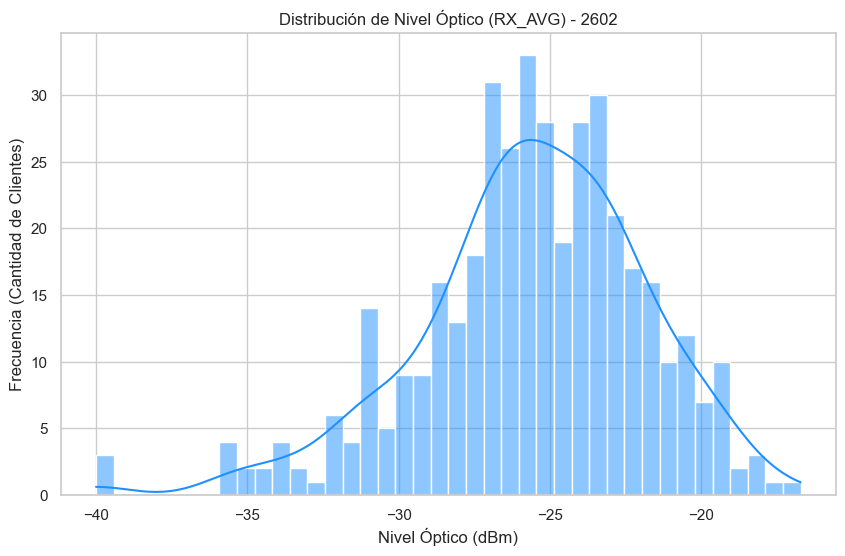

   Generando Barras Horizontales de MOTIVO_PEDIDO...


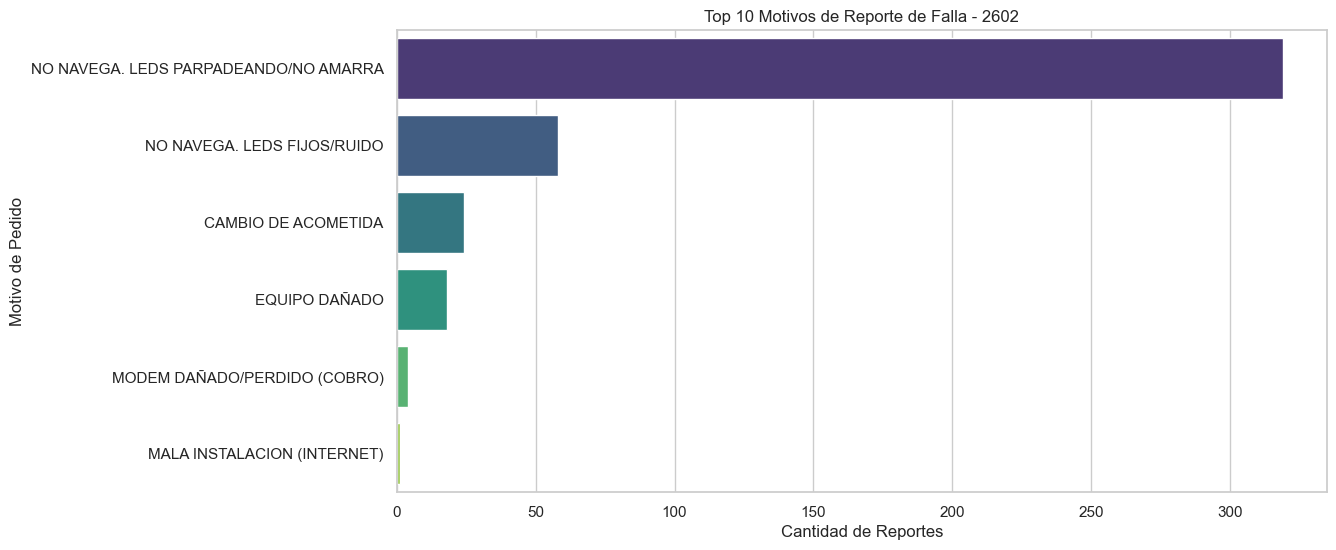

   Generando Gráfico de Donut de ONT_MODEL...


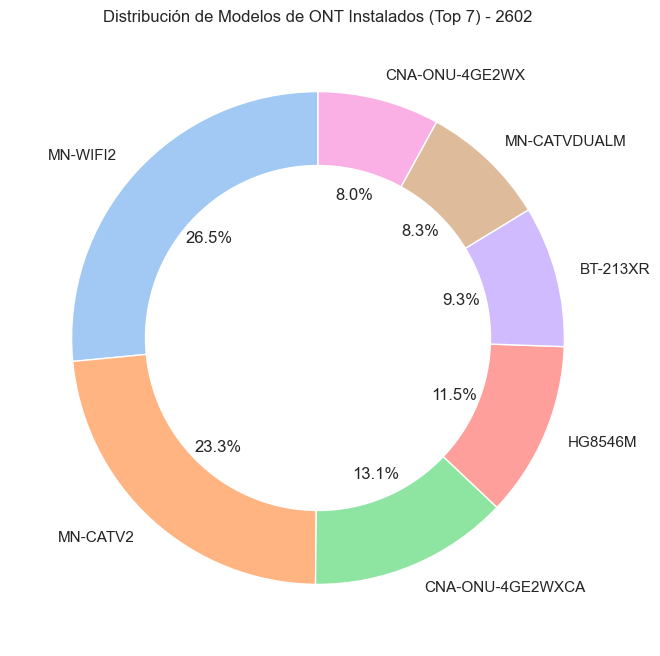

[EXITO] Gráficos generados y guardados en la carpeta 'graficos_eda_2602'.


In [2]:
import pandas as pd #Importar librería pandas
import matplotlib.pyplot as plt #Importar librería pyplot
import seaborn as sns #Importar librería seaborn
import os #Importar módulo sistema
import json #Importar módulo json
from datetime import datetime #Importar formateo de fechas

# Cargar configuración desde JSON
with open('config_eda.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['eda_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['eda_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

#Construir nombres de archivo y carpeta dinámicos con AAMM
FILE_INPUT = f"../ETL/datalake/gold/clean/dataset_master_gold_{str_yymm}.parquet" #Definir ruta origen relativa dinámica
RUTA_SALIDA = f"graficos_eda_{str_yymm}" #Definir carpeta salida dinámica

if not os.path.exists(RUTA_SALIDA): #Verificar existencia carpeta
    os.makedirs(RUTA_SALIDA) #Crear carpeta graficos

def generar_graficos_univariados(): #Definir función principal
    print(f"Iniciando generación de gráficos univariados para el periodo {str_yymm}...") #Imprimir inicio proceso
    
    try: #Iniciar bloque prueba
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
        print("[EXITO] Archivo Parquet cargado correctamente.") #Imprimir éxito
    except FileNotFoundError: #Capturar error archivo
        print(f"[ERROR] No se encontró el archivo en: {FILE_INPUT}") #Imprimir error ruta
        return #Salir de función
        
    sns.set_theme(style="whitegrid") #Establecer estilo visual
    
    print("   Generando Histograma de RX_AVG...") #Imprimir estado proceso
    plt.figure(figsize=(10, 6)) #Configurar tamaño figura
    #Dibujar histograma con línea de tendencia (kde)
    sns.histplot(data=df, x='RX_AVG', bins=40, kde=True, color='dodgerblue') #Crear histograma
    plt.title(f'Distribución de Nivel Óptico (RX_AVG) - {str_yymm}') #Añadir título principal con fecha
    plt.xlabel('Nivel Óptico (dBm)') #Añadir etiqueta X
    plt.ylabel('Frecuencia (Cantidad de Clientes)') #Añadir etiqueta Y
    plt.savefig(f"{RUTA_SALIDA}/01_histograma_rx_avg_{str_yymm}.png", bbox_inches='tight') #Guardar gráfico png dinámico
    plt.show() #Mostrar Grafico
    
    print("   Generando Barras Horizontales de MOTIVO_PEDIDO...") #Imprimir estado proceso
    plt.figure(figsize=(12, 6)) #Configurar tamaño figura
    df['MOTIVO_PEDIDO'] = df['MOTIVO_PEDIDO'].str.replace('DA?ADO', 'DAÑADO', regex=False) #Corregir codificacion manual
    df['MOTIVO_PEDIDO'] = df['MOTIVO_PEDIDO'].str.replace('DAADO', 'DAÑADO', regex=False) #Corregir simbolo roto
    top_motivos = df['MOTIVO_PEDIDO'].value_counts().head(10) #Obtener top 10 frecuencias
    #Dibujar barras horizontales para textos largos
    sns.barplot(x=top_motivos.values, y=top_motivos.index, hue=top_motivos.index, palette='viridis', legend=False) #Crear gráfico barras
    plt.title(f'Top 10 Motivos de Reporte de Falla - {str_yymm}') #Añadir título principal con fecha
    plt.xlabel('Cantidad de Reportes') #Añadir etiqueta X
    plt.ylabel('Motivo de Pedido') #Añadir etiqueta Y
    plt.savefig(f"{RUTA_SALIDA}/02_barras_motivo_pedido_{str_yymm}.png", bbox_inches='tight') #Guardar gráfico png dinámico
    plt.show() #Mostrar Grafico
    
    print("   Generando Gráfico de Donut de ONT_MODEL...") #Imprimir estado proceso
    plt.figure(figsize=(8, 8)) #Configurar tamaño figura
    df['ONT_MODEL'] = df['ONT_MODEL'].fillna('DESCONOCIDO') #Imputar nulos temporalmente
    df['ONT_MODEL'] = df['ONT_MODEL'].replace(['nan', 'NaN', 'NAN'], 'DESCONOCIDO') #Reemplazar falsos nulos
    top_modelos = df['ONT_MODEL'].value_counts().head(7) #Obtener top 7 modelos
    #Dibujar pastel base
    plt.pie(top_modelos.values, labels=top_modelos.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')) #Crear gráfico pastel
    #Crear círculo central blanco para efecto Donut
    circulo_centro = plt.Circle((0,0), 0.70, fc='white') #Crear circulo blanco
    fig = plt.gcf() #Obtener figura actual
    fig.gca().add_artist(circulo_centro) #Añadir circulo a figura
    plt.title(f'Distribución de Modelos de ONT Instalados (Top 7) - {str_yymm}') #Añadir título principal con fecha
    plt.savefig(f"{RUTA_SALIDA}/03_donut_ont_model_{str_yymm}.png", bbox_inches='tight') #Guardar gráfico png dinámico
    plt.show() #Mostrar Grafico
    
    print(f"[EXITO] Gráficos generados y guardados en la carpeta '{RUTA_SALIDA}'.") #Imprimir éxito final

if __name__ == "__main__": #Verificar ejecución directa
    generar_graficos_univariados() #Ejecutar función principal

## GRAFICOS PARA ANALISIS CON RELACION ENTRE VARIABLES

Iniciando generación de gráficos enfocados a negocio y churn para 2602...
[EXITO] Archivo Parquet cargado correctamente.

   Generando Gráfico: Zonas con más demora...


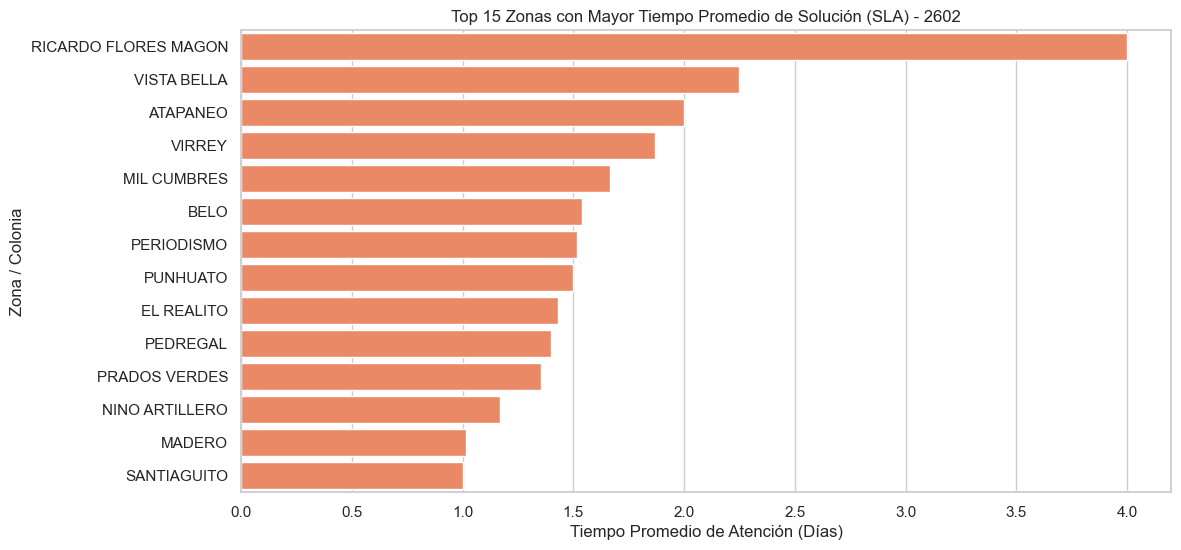


   Generando Gráfico Core: Identificando motivo de bajas...


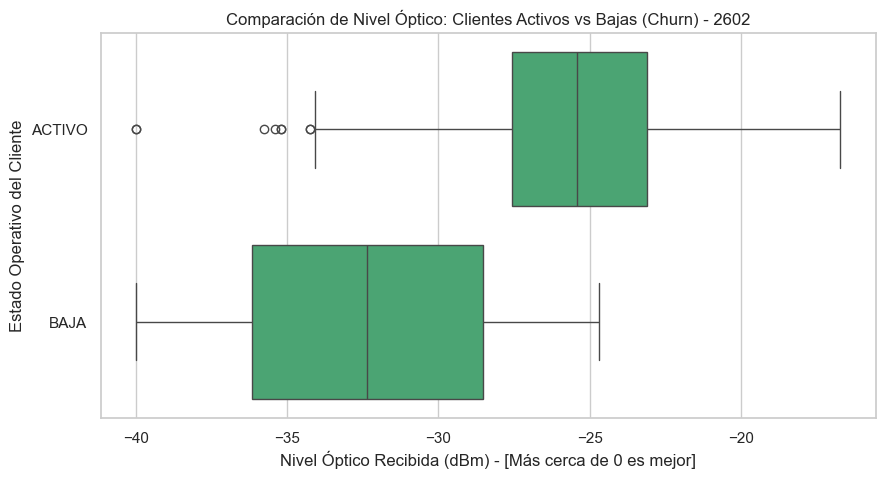


[EXITO] Gráficos de negocio guardados en 'graficos_eda_2602'.


In [3]:
import pandas as pd #Importar librería pandas
import matplotlib.pyplot as plt #Importar librería pyplot
import seaborn as sns #Importar librería seaborn
import os #Importar módulo sistema
import json #Importar módulo json
from datetime import datetime #Importar formateo de fechas

#Cargar configuración desde JSON
with open('config_eda.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['eda_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['eda_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

FILE_INPUT = f"../ETL/datalake/gold/clean/dataset_master_gold_{str_yymm}.parquet" #Definir ruta origen relativa
RUTA_SALIDA = f"graficos_eda_{str_yymm}" #Definir carpeta salida

if not os.path.exists(RUTA_SALIDA): #Verificar existencia carpeta
    os.makedirs(RUTA_SALIDA) #Crear carpeta graficos

def generar_graficos_negocio(): #Definir función principal
    print(f"Iniciando generación de gráficos enfocados a negocio y churn para {str_yymm}...") #Imprimir inicio proceso
    
    try: #Iniciar bloque prueba
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
        print("[EXITO] Archivo Parquet cargado correctamente.") #Imprimir éxito
    except FileNotFoundError: #Capturar error archivo
        print(f"[ERROR] No se encontró el archivo en: {FILE_INPUT}") #Imprimir error ruta
        return #Salir de función
        
    sns.set_theme(style="whitegrid") #Establecer estilo visual
    
    df['ONT_MODEL'] = df['ONT_MODEL'].replace(['nan', 'NaN', 'NAN'], 'DESCONOCIDO') #Reemplazar falsos nulos
    df['ONT_MODEL'] = df['ONT_MODEL'].fillna('DESCONOCIDO') #Imputar nulos reales
    
    print("\n   Generando Gráfico: Zonas con más demora...") #Imprimir estado proceso
    plt.figure(figsize=(12, 6)) #Configurar tamaño figura
    
    tiempo_zona = df.groupby('ZONA')['DIAS_ATENCION'].mean().sort_values(ascending=False).head(15) #Calcular promedio tiempo
    
    sns.barplot(x=tiempo_zona.values, y=tiempo_zona.index, color='coral') #Crear grafico barras
    
    plt.title(f'Top 15 Zonas con Mayor Tiempo Promedio de Solución (SLA) - {str_yymm}') #Añadir titulo principal
    plt.xlabel('Tiempo Promedio de Atención (Días)') #Añadir etiqueta X
    plt.ylabel('Zona / Colonia') #Añadir etiqueta Y
    plt.savefig(f"{RUTA_SALIDA}/02_zona_vs_tiempo_{str_yymm}.png", bbox_inches='tight', dpi=300) #Guardar grafico alta resolucion
    plt.show() #Mostrar grafico consola
    
    #El objetivo principal del negocio: ¿Por qué cancelan?
    print("\n   Generando Gráfico Core: Identificando motivo de bajas...") #Imprimir estado proceso
    plt.figure(figsize=(10, 5)) #Configurar tamaño figura
    
    df_estado = df[df['ESTATUS_x'].isin(['ACTIVO', 'BAJA'])].copy() #Filtrar base de datos
    
    #Boxplot para ver si la señal física de los cancelados era peor
    sns.boxplot(data=df_estado, x='RX_AVG', y='ESTATUS_x', color='mediumseagreen') #Crear grafico caja
    
    plt.title(f'Comparación de Nivel Óptico: Clientes Activos vs Bajas (Churn) - {str_yymm}') #Añadir titulo principal
    plt.xlabel('Nivel Óptico Recibida (dBm) - [Más cerca de 0 es mejor]') #Añadir etiqueta X
    plt.ylabel('Estado Operativo del Cliente') #Añadir etiqueta Y
    plt.savefig(f"{RUTA_SALIDA}/03_churn_vs_potencia_{str_yymm}.png", bbox_inches='tight', dpi=300) #Guardar grafico alta resolucion
    plt.show() #Mostrar grafico consola

    print(f"\n[EXITO] Gráficos de negocio guardados en '{RUTA_SALIDA}'.") #Imprimir éxito final

if __name__ == "__main__": #Verificar ejecución directa
    generar_graficos_negocio() #Ejecutar función principal

## GRAFICOS PARA EVALUAR MODELO DE ONTS POR TASA DE REINCIDENCIA

Iniciando cálculo de Tasa de Reincidencia por Modelo para 2602...


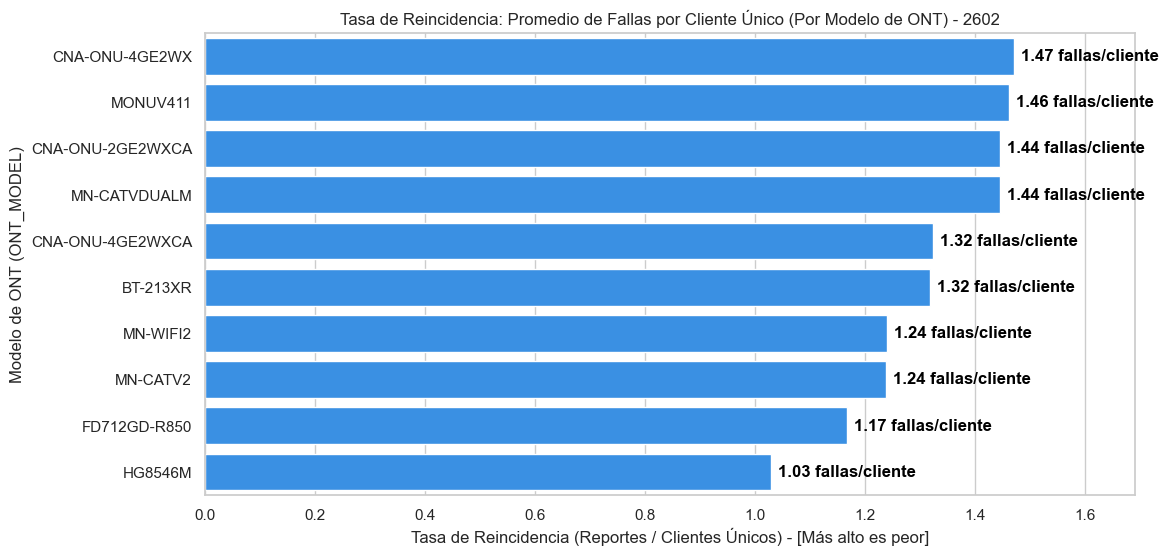


[EXITO] Gráfico de Tasa de Reincidencia guardado en 'graficos_eda_2602'.


In [4]:
import pandas as pd #Importar librería pandas
import matplotlib.pyplot as plt #Importar librería pyplot
import seaborn as sns #Importar librería seaborn
import os #Importar módulo sistema
import json #Importar módulo json
from datetime import datetime #Importar formateo de fechas

#Cargar configuración desde JSON
with open('config_eda.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['eda_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['eda_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

FILE_INPUT = f"../ETL/datalake/gold/clean/dataset_master_gold_{str_yymm}.parquet" #Definir ruta origen relativa
RUTA_SALIDA = f"graficos_eda_{str_yymm}" #Definir carpeta salida

if not os.path.exists(RUTA_SALIDA): #Verificar existencia carpeta
    os.makedirs(RUTA_SALIDA) #Crear carpeta graficos

def generar_grafico_ont(): #Definir función principal
    print(f"Iniciando cálculo de Tasa de Reincidencia por Modelo para {str_yymm}...") #Imprimir inicio proceso
    
    try: #Iniciar bloque prueba
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet
    except FileNotFoundError: #Capturar error archivo
        print(f"[ERROR] No se encontró el archivo en: {FILE_INPUT}") #Imprimir error ruta
        return #Salir de función
        
    sns.set_theme(style="whitegrid") #Establecer estilo visual
    
    df['ONT_MODEL'] = df['ONT_MODEL'].replace(['nan', 'NaN', 'NAN'], 'DESCONOCIDO') #Reemplazar falsos nulos
    df['ONT_MODEL'] = df['ONT_MODEL'].fillna('DESCONOCIDO') #Imputar nulos reales
    
    #Obtener los 10 modelos con más fallas en volumen para tener significancia estadística
    top_10_volumen = df['ONT_MODEL'].value_counts().head(10).index #Obtener nombres top 10
    df_top = df[df['ONT_MODEL'].isin(top_10_volumen)] #Filtrar base a top 10
    
    total_fallas = df_top['ONT_MODEL'].value_counts() #Contar reportes brutos
    modems_unicos = df_top.groupby('ONT_MODEL')['CONTRATO'].nunique() #Contar clientes unicos
    
    tasa_reincidencia = (total_fallas / modems_unicos).sort_values(ascending=False) #Calcular y ordenar tasa
    
    plt.figure(figsize=(12, 6)) #Configurar tamaño figura
    
    #Crear gráfico de barras con la tasa justa
    ax = sns.barplot(x=tasa_reincidencia.values, y=tasa_reincidencia.index, color='dodgerblue') #Crear grafico
    
    #Agregar el valor numérico (Tasa) al final de cada barra
    for i in ax.containers: #Iterar sobre contenedores de barras
        ax.bar_label(i, fmt='%.2f fallas/cliente', padding=5, color='black', weight='bold') #Añadir etiqueta de datos
        
    plt.title(f'Tasa de Reincidencia: Promedio de Fallas por Cliente Único (Por Modelo de ONT) - {str_yymm}') #Añadir titulo
    plt.xlabel('Tasa de Reincidencia (Reportes / Clientes Únicos) - [Más alto es peor]') #Añadir etiqueta X
    plt.ylabel('Modelo de ONT (ONT_MODEL)') #Añadir etiqueta Y
    
    #Ajustar el límite X para que el texto no se corte
    plt.xlim(0, tasa_reincidencia.max() * 1.15) #Aumentar limite X
    
    plt.savefig(f"{RUTA_SALIDA}/01_ont_vs_tasa_reincidencia_{str_yymm}.png", bbox_inches='tight', dpi=300) #Guardar grafico alta resolucion
    plt.show() #Mostrar grafico consola

    print(f"\n[EXITO] Gráfico de Tasa de Reincidencia guardado en '{RUTA_SALIDA}'.") #Imprimir éxito final

if __name__ == "__main__": #Verificar ejecución directa
    generar_grafico_ont() #Ejecutar función principal